In [2]:
import glob
import re
import os

import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fontsize = 14
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "cm",
    "font.size": fontsize,
    #'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents} \usepackage{mathrsfs} \usepackage{bm}',
    'text.latex.preamble': r'\usepackage{bm}',
    'figure.dpi': 200
})

In [4]:
from typing import Dict, Tuple, Optional

def get_last_file(path : Path) -> Path | None:
    files = []
    pattern = os.path.join(path, "TR_IRGNM_*.pkl")
    files += glob.glob(pattern)
    pattern = os.path.join(path, "FOM_IRGNM_*.pkl")
    files += glob.glob(pattern)

    indices = []
    for f in files:
        match = re.search(r'(?:TR|FOM)_IRGNM_(\d+)\.pkl$', f)
        if match:
            idx = int(match.group(1))
            indices.append((idx, f))
    
    if indices:
        _, max_file = max(indices, key=lambda x: x[0])
        
        return Path(max_file).name
    else:
        print("No matching files found.")

    return None

def filter_and_reorder(d: Dict, pattern: str = r'.*FOM.*') -> Tuple[Dict, Optional[str]]:
    regex = re.compile(pattern)
    matching = [k for k in d if regex.search(k)]
    non_matching = [k for k in d if k not in matching]

    # Sort keys alphabetically within each group
    non_matching_sorted = sorted(non_matching)
    matching_sorted = sorted(matching)

    # Build the reordered dict: alphabetically sorted non-matching first, then matching ones
    reordered = {k: d[k] for k in non_matching_sorted}
    reordered.update({k: d[k] for k in matching_sorted})

    # Return reordered dict and the single matching key (if exactly one match)
    if len(matching_sorted) == 1:
        return reordered, matching_sorted[0]
    else:
        return reordered, None

In [10]:
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
WORK_DIR = Path('/home/dealii/workdir/experiments')
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
#SAVE_PATH = Path('/home/benedikt/Dokumente/Paper/linear_elasticity/figures/experiments')


SAVE_PATH = Path('/home/dealii/workdir/figs')

subset = 'baseline'
obs_op = 'sensors'
data_dir_path = WORK_DIR / 'baseline_x_bodyforce'

pattern = re.compile(rf'^{subset}_.*')

experiment_names = [
    d.name for d in data_dir_path.iterdir()
    if d.is_dir() and pattern.match(d.name)
]

data_paths = [ data_dir_path / experiment_name for experiment_name in experiment_names]
file_names = [get_last_file(data_path) for data_path in data_paths]

#print(data_paths)
#print(file_names)

setup = None
data = {}
optimizer_parameters = {}

for (data_path, file_name) in zip(data_paths, file_names):            

    try:
        with open(data_path / file_name, 'rb') as file:
            data_ = load(file)
        data[str(data_path.name)] = data_
    except TypeError:
        print(f"Can not find dumps for {data_path}")
    except:
        print(f"Can not open {data_path / file_name}")

    if not setup:
        with open(data_path / 'setup.pkl', 'rb') as file:
            setup = load(file)

    
    optimizer_parameter_path = data_path / 'optimizer_parameter.pkl'
    with open(optimizer_parameter_path, 'rb') as file:
        optimizer_parameter = load(file)
        
    optimizer_parameters[str(data_path.name)] = optimizer_parameter

data, FOM_key = filter_and_reorder(data, pattern=r'.*FOM.*')
#assert FOM_key

# if not 'FOM' in locals():
#     FOM = build_InstationaryModelIP(setup=setup)



In [8]:
data_dir_path

PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce')

In [11]:
data_paths

[PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce/baseline_FOM_identity'),
 PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce/baseline_FOM_sensors'),
 PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce/baseline_TR_identity'),
 PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce/baseline_TR_identity_HaPOD_tol_1e-3'),
 PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce/baseline_TR_identity_include_all_lins_HaPOD_tol_1e-3'),
 PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce/baseline_TR_identity_include_each_time_step'),
 PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce/baseline_TR_identity_no_HaPOD'),
 PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce/baseline_TR_sensors'),
 PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce/baseline_TR_sensors_HaPOD_tol_1e-3'),
 PosixPath('/home/dealii/workdir/experiments/baseline_x_bodyforce/baseline_TR_sensors_include_all

In [ ]:
file_names

In [ ]:
experiment_names

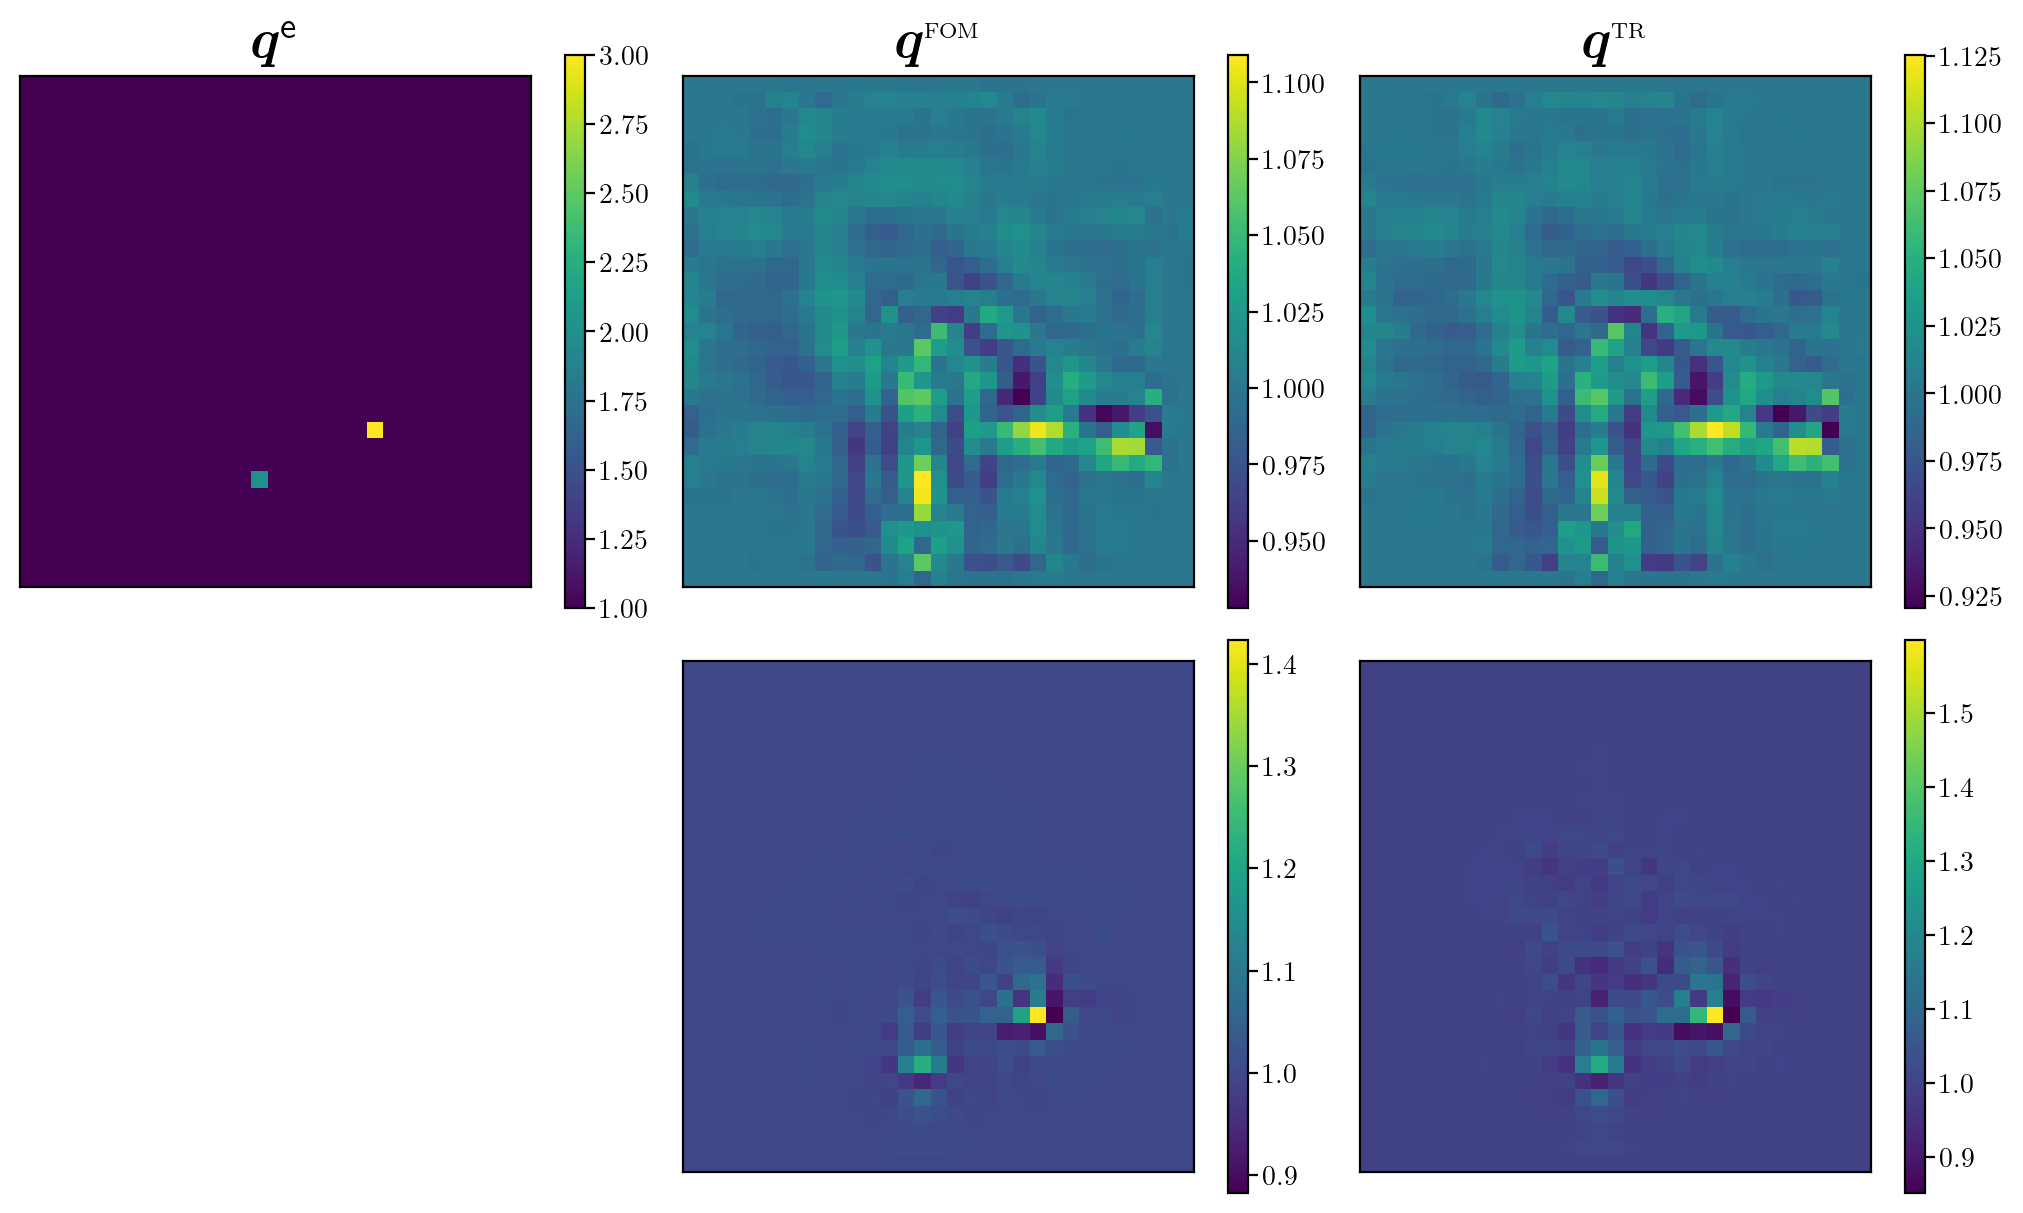

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from pathlib import Path

plt.rcParams.update({"font.size": 16})

title_pad = 7
time_step = 0
time_dep = False
idx = -1

FOM_keys = [f'{subset}_FOM_sensors', f'{subset}_FOM_identity']
TR_keys = [f'{subset}_TR_sensors', f'{subset}_TR_identity']
# FOM_keys = [f'{subset}_1.0_FOM_sensors', 
#             f'{subset}_1.0_FOM_identity', 
#             f'{subset}_2.0_FOM_sensors', 
#             f'{subset}_2.0_FOM_identity', 
#             f'{subset}_5.0_FOM_sensors', 
#             f'{subset}_5.0_FOM_identity']

# TR_keys = [f'{subset}_1.0_TR_sensors', 
#            f'{subset}_1.0_TR_identity', 
#            f'{subset}_2.0_TR_sensors', 
#            f'{subset}_2.0_TR_identity', 
#            f'{subset}_5.0_TR_sensors', 
#            f'{subset}_5.0_TR_identity']
assert len(FOM_keys) == len(TR_keys)

#assert np.all(np.array([TR_key in data.keys() for TR_key in TR_keys]))


fig = plt.figure(figsize=(10, len(TR_keys) * 3), constrained_layout=True)  # use constrained_layout

width_ratios = [1, 0.04] * 3
#width_ratios.append([1, 0.04] * 3)
# for _ in range(len(TR_keys)):
#     width_ratios.append([1, 0.04] * 3)


gs = gridspec.GridSpec(
    len(TR_keys), 6,
    figure=fig,
    width_ratios=width_ratios,  # give bars a bit more room
    wspace=0.1
)

ax = []
cax = []

for i in range(len(TR_keys)):

    ax0 = fig.add_subplot(gs[i, 0]); cax0 = fig.add_subplot(gs[i, 1])
    ax1 = fig.add_subplot(gs[i, 2]); cax1 = fig.add_subplot(gs[i, 3])
    ax2 = fig.add_subplot(gs[i, 4]); cax2 = fig.add_subplot(gs[i, 5])

    ax.append([ax0,ax1,ax2])
    cax.append([cax0,cax1,cax2])

# --- build grid (assuming q_* are defined on a square grid) ---
x = np.arange(-15, 16)
y = np.arange(-15, 16)
X, Y = np.meshgrid(x, y)

titles = [
    rf'$\bm{{q}}^{{\mathsf e}}$' if not time_dep else rf'$\bm{{q}}^{{{time_step}}}_\mathsf e$',
    rf'$\bm{{q}}^{{\textrm{{\footnotesize FOM}}}}$' if not time_dep else rf'$\bm{{q}}^{{{time_step}}}_\textrm{{\footnotesize FOM}}$',
    rf'$\bm{{q}}^{{\textrm{{\footnotesize TR}}}}$' if not time_dep else rf'$\bm{{q}}^{{{time_step}}}_\textrm{{\footnotesize TR}}$'
]

# --- Plot with imshow + perfectly aligned colorbars ---
for i in range(len(TR_keys)):
    
    q_exact = setup['q_exact'][time_step, :]
    q_FOM   = data[FOM_keys[i]]['q'][idx].to_numpy()[time_step, :]
    q_TR    = data[TR_keys[i]]['q'][idx].to_numpy()[time_step, :]
    
    # reshape
    nx, ny = X.shape
    q_exact = q_exact.reshape(nx, ny)
    q_FOM   = q_FOM.reshape(nx, ny)
    q_TR    = q_TR.reshape(nx, ny)

    if i == 0:
        datasets = [q_exact, q_FOM, q_TR]
    else:
        datasets = [None, q_FOM, q_TR]

    for ax_, cax_, q, title in zip(ax[i], cax[i], datasets, titles):
        if q is None:
            ax_.axis('off')
            cax_.axis('off')
            continue
        if i == 0:
            ax_.set_title(title, pad=title_pad)
        
        vmin, vmax = q.min(), q.max()
        im = ax_.imshow(q, origin="lower", extent=[x.min(), x.max(), y.min(), y.max()],
                        cmap="viridis", vmin=vmin, vmax=vmax, aspect="equal")
        
        ax_.set_xticks([])
        ax_.set_yticks([])
        cb = fig.colorbar(im, cax=cax_)  # fills cax, same height as plot
        cb.ax.tick_params(labelsize=10, pad=2)


# # --- Show ---
plt.show()
#fig.savefig(SAVE_PATH / Path(f'{subset}_reconst_param.pdf'), bbox_inches="tight")

In [14]:
import itertools

In [16]:
a = [1,2,3]
b = [1,2,3]
for noise_level,alpha_0 in itertools.product(a,b):
    print(noise_level)

1
1
1
2
2
2
3
3
3
